# Configuration

In [2]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

from typing import Union, List, Iterable
from joblib import Parallel, delayed, cpu_count
from datetime import datetime 

In [3]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [4]:
from statsmodels.regression.linear_model import OLS

In [5]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [6]:
from core.variables import *
from core.dgp import SingleSegment
import core.multiple_treatments_single_segment as mtss

# DGP

In [6]:
dgp_params = {
    'te': 0.6,
    'noise_std': 2,
    'treatment_space': np.array([0, 1, 2, 3, 4])
}

dgp = SingleSegment(**dgp_params)
treatment_arr, outcome_arr = dgp.sample(sample_size=1000, seed=0)

# Demand Model

In [7]:
emp_te_arr = mtss.difference_in_mean(
    treatments=treatment_arr, outcomes=outcome_arr,
    treatment_vals=dgp_params['treatment_space']
)

# display
for idx, te_est in enumerate(emp_te_arr):
    if idx == 0:
        continue 
    
    print(f'Treatment value: {dgp.treatment_space[idx]}, Estiamted TE: {te_est:.4f}, True TE: {dgp.lift_arr[idx]:.4f}')

Treatment value: 1, Estiamted TE: 0.6710, True TE: 0.6000
Treatment value: 2, Estiamted TE: 1.0295, True TE: 1.2000
Treatment value: 3, Estiamted TE: 1.9261, True TE: 1.8000
Treatment value: 4, Estiamted TE: 2.3537, True TE: 2.4000


# Optimization

In [8]:
plugin_decision, plugin_val_est = mtss.optimize(
    customer_tes=emp_te_arr, 
    treatment_space=dgp_params['treatment_space'],
    price=1, cost=0.5
)

true_plugin_val = mtss.obj_func(
    customer_tes=dgp.lift_arr, 
    targ_decision=plugin_decision,
    price=1, cost=0.5
)

print(f'Estimated targing value: {plugin_val_est:.4f}, True targeting value: {true_plugin_val:.4f}')

Estimated targing value: 0.4261, True targeting value: 0.3000


# Winner's Curse

In [9]:
operations_params = {'price': 1, 'cost': 0.5}
dgp_params = {
    'te': 0.6,
    'noise_std': 2,
    'treatment_space': np.array([0, 1, 2, 3, 4])
}
data_params = {'sample_size': 100}
experiment_params = {'n_experiments': 5000}

estimators_dict = {}

result_records = mtss.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, verbose=True
)

emp_wc_arr = np.array([record['plugin_wc'] for record in result_records])
emp_wc_pct_arr = np.array([record['plugin_wc_pct'] for record in result_records])

avg_wc_pct = 100 * np.nanmean(emp_wc_pct_arr)
se_wc_pct = 100 * np.nanstd(emp_wc_pct_arr) / np.sqrt(data_params['sample_size'])

print(f"Average plugin winner's curse: {avg_wc_pct:.4f}% ({se_wc_pct:.4f}%)")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 156 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 2112 tasks      | elapsed:    1.2s


Average plugin winner's curse: 254.9123% (29.7989%)


[Parallel(n_jobs=-1)]: Done 4672 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    1.4s finished


# Estimating winner's curse

## Standard Bootstrap

In [10]:
dgp = SingleSegment(**dgp_params)
treatment_arr, outcome_arr = dgp.sample(**data_params, seed=1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.0s finished


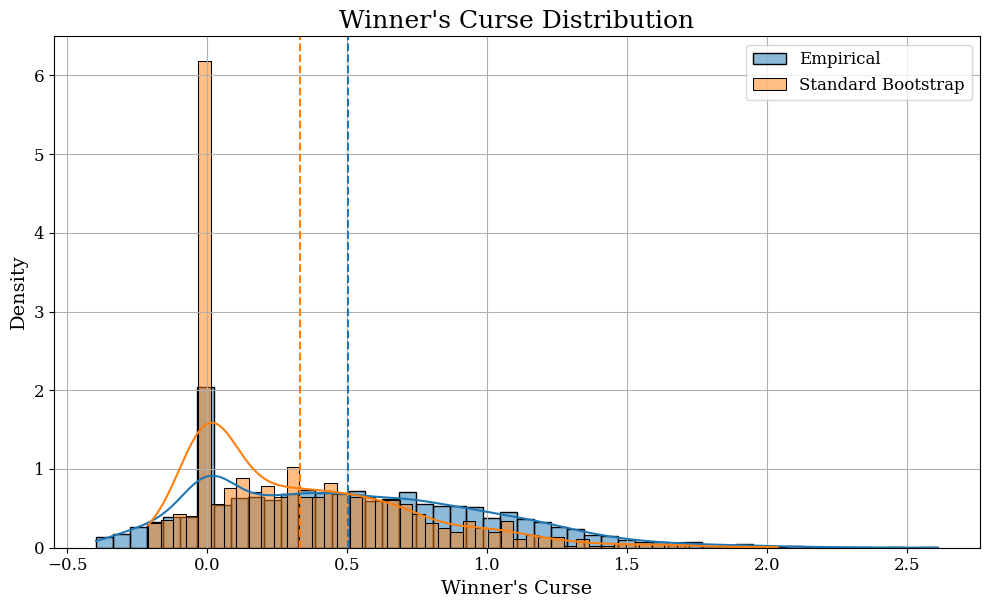

In [11]:
boot_wc_dstn_arr = mtss.get_wc_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    treatment_space=dgp_params['treatment_space'],
    price=1, cost=0.5,
    n_bootstraps=1000, n_jobs=-1, verbose=True
)

fig, ax = plt.subplots(figsize=(10, 6.18))

# empirical winner's curse
sns.histplot(emp_wc_arr, bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=ax)
ax.axvline(np.nanmean(emp_wc_arr), color='C0', linestyle='--')

# bootstrap winner's curse
sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C1', label='Standard Bootstrap', ax=ax)
ax.axvline(np.nanmean(boot_wc_dstn_arr), color='C1', linestyle='--')

ax.set_title('Winner\'s Curse Distribution', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()
plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.0s finished


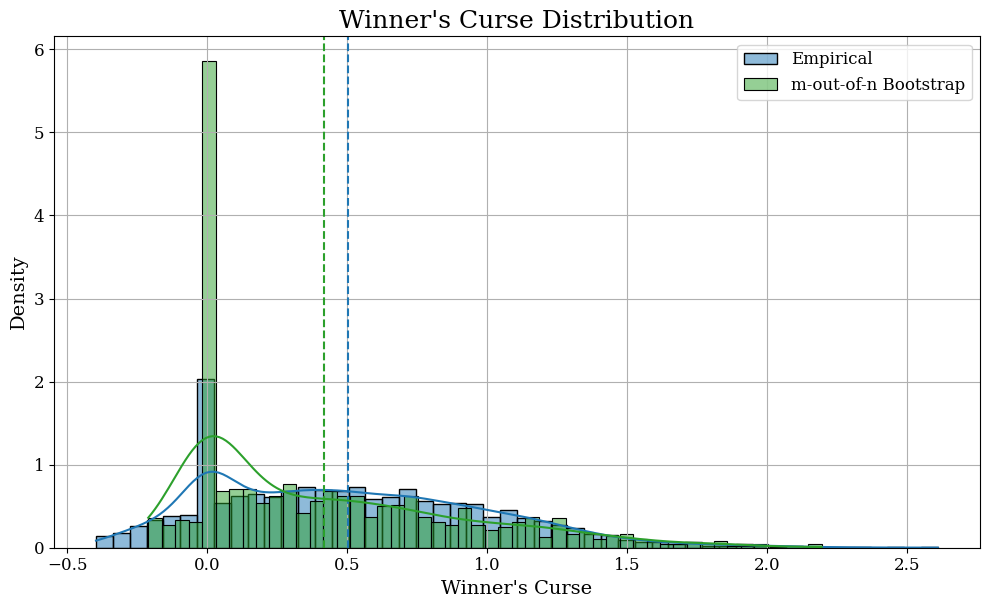

In [12]:
mn_boot_wc_dstn_arr = mtss.get_wc_m_out_of_n_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    treatment_space=dgp_params['treatment_space'],
    price=1, cost=0.5,
    n_bootstraps=1000, power=0.9, 
    n_jobs=-1, verbose=True
)

fig, ax = plt.subplots(figsize=(10, 6.18))

# empirical winner's curse
sns.histplot(emp_wc_arr, bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=ax)
ax.axvline(np.nanmean(emp_wc_arr), color='C0', linestyle='--')

# bootstrap winner's curse
sns.histplot(mn_boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C2', label='m-out-of-n Bootstrap', ax=ax)
ax.axvline(np.nanmean(mn_boot_wc_dstn_arr), color='C2', linestyle='--')

ax.set_title('Winner\'s Curse Distribution', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()
plt.tight_layout()
plt.show()

## Numerical Bootstrap

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


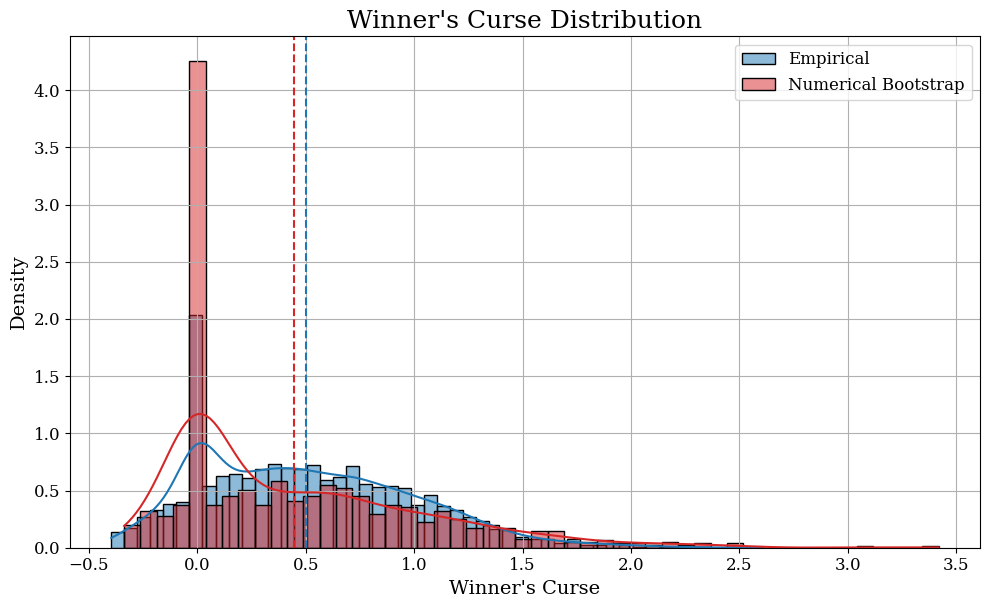

In [13]:
num_boot_wc_dstn_arr = mtss.get_wc_num_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    treatment_space=dgp_params['treatment_space'],
    price=1, cost=0.5,
    n_bootstraps=1000, power=-0.4, 
    n_jobs=-1, verbose=True
)

fig, ax = plt.subplots(figsize=(10, 6.18))

# empirical winner's curse
sns.histplot(emp_wc_arr, bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=ax)
ax.axvline(np.nanmean(emp_wc_arr), color='C0', linestyle='--')

# bootstrap winner's curse
sns.histplot(num_boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C3', label='Numerical Bootstrap', ax=ax)
ax.axvline(np.nanmean(num_boot_wc_dstn_arr), color='C3', linestyle='--')

ax.set_title('Winner\'s Curse Distribution', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()
plt.tight_layout()
plt.show()

# Bias Correction

In [14]:
operations_params = {'price': 1, 'cost': 0.5}
dgp_params = {
    'te': 0.6,
    'noise_std': 2,
    'treatment_space': np.array([0, 1, 2, 3, 4])
}
data_params = {'sample_size': 100}
experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 500, 'n_jobs': 1}
    }, 
    'mn_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 500, 'power': 0.9, 'n_jobs': 1}
    }, 
    'num_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 500, 'power': -0.45, 'n_jobs': 1}
    }
}

In [15]:
result_records = mtss.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   13.7s finished


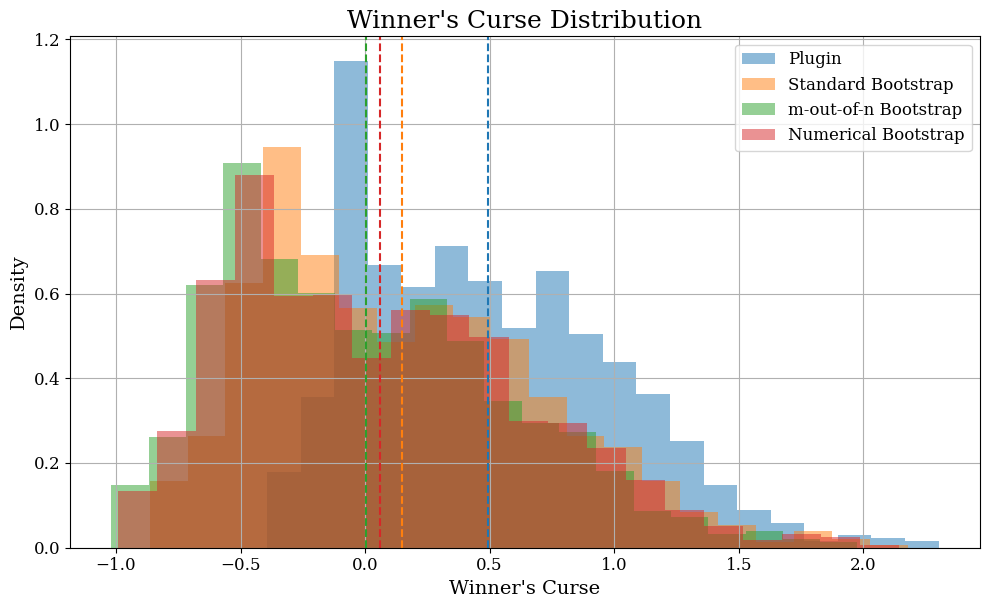

In [16]:
result_df = pd.DataFrame.from_records(result_records)
result_df = result_df[[col for col in result_df if col.endswith('wc')]]
# turn inf to nan
result_df.replace([np.inf, -np.inf], np.nan, inplace=True)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# historgram of plugin estimator's winner's curse
sns.histplot(result_df['plugin_wc'], bins=20, kde=False, alpha=0.5, stat='density', ax=ax, color='C0', edgecolor=None, label='Plugin')
ax.axvline(result_df['plugin_wc'].mean(), color='C0', linestyle='--')

# historgram of standard bootstrap estimator's winner's curse
sns.histplot(result_df['standard_bootstrap_wc'], bins=20, kde=False, alpha=0.5, stat='density', ax=ax, color='C1', edgecolor=None, label='Standard Bootstrap')
ax.axvline(np.nanmean(result_df['standard_bootstrap_wc']), color='C1', linestyle='--')

# historgram of m-out-of-n bootstrap estimator's winner's curse
sns.histplot(result_df['mn_bootstrap_wc'], bins=20, kde=False, alpha=0.5, stat='density', ax=ax, color='C2', edgecolor=None, label='m-out-of-n Bootstrap')
ax.axvline(np.nanmean(result_df['mn_bootstrap_wc']), color='C2', linestyle='--')

# historgram of numerical bootstrap estimator's winner's curse
sns.histplot(result_df['num_bootstrap_wc'], bins=20, kde=False, alpha=0.5, stat='density', ax=ax, color='C3', edgecolor=None, label='Numerical Bootstrap')
ax.axvline(result_df['num_bootstrap_wc'].mean(), color='C3', linestyle='--')

ax.set_title('Winner\'s Curse Distribution', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

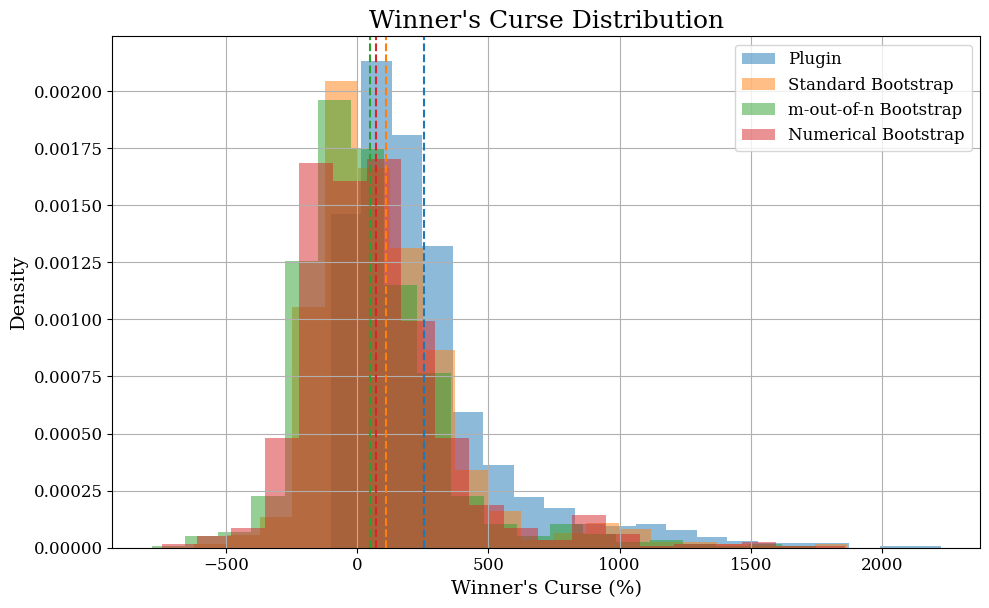

In [17]:
result_df = pd.DataFrame.from_records(result_records)
result_df = 100 * result_df[[col for col in result_df if col.endswith('wc_pct')]]
# turn inf to nan
result_df.replace([np.inf, -np.inf], np.nan, inplace=True)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# historgram of plugin estimator's winner's curse
sns.histplot(result_df['plugin_wc_pct'], bins=20, kde=False, alpha=0.5, stat='density', ax=ax, color='C0', edgecolor=None, label='Plugin')
ax.axvline(result_df['plugin_wc_pct'].mean(), color='C0', linestyle='--')

# historgram of standard bootstrap estimator's winner's curse
sns.histplot(result_df['standard_bootstrap_wc_pct'], bins=20, kde=False, alpha=0.5, stat='density', ax=ax, color='C1', edgecolor=None, label='Standard Bootstrap')
ax.axvline(np.nanmean(result_df['standard_bootstrap_wc_pct']), color='C1', linestyle='--')

# historgram of m-out-of-n bootstrap estimator's winner's curse
sns.histplot(result_df['mn_bootstrap_wc_pct'], bins=20, kde=False, alpha=0.5, stat='density', ax=ax, color='C2', edgecolor=None, label='m-out-of-n Bootstrap')
ax.axvline(np.nanmean(result_df['mn_bootstrap_wc_pct']), color='C2', linestyle='--')

# historgram of numerical bootstrap estimator's winner's curse
sns.histplot(result_df['num_bootstrap_wc_pct'], bins=20, kde=False, alpha=0.5, stat='density', ax=ax, color='C3', edgecolor=None, label='Numerical Bootstrap')
ax.axvline(result_df['num_bootstrap_wc_pct'].mean(), color='C3', linestyle='--')

ax.set_title('Winner\'s Curse Distribution', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Sensitivity Analysis

## Sample Size

In [32]:
operations_params = {'price': 1, 'cost': 0.5}
dgp_params = {
    'te': 0.6,
    'noise_std': 2,
    'treatment_space': np.array([0, 1, 2, 3, 4])
}
data_params = {'sample_size': np.nan}
experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 500, 'n_jobs': 1}
    }, 
    'mn_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 500, 'power': 0.95, 'n_jobs': 1}
    }, 
    'num_bootstrap': {
        'estimator': mtss.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 500, 'power': -0.45, 'n_jobs': 1}
    }
}

In [ ]:
sample_size_result_dict = mtss.sample_size_test(
    sample_sizes=[100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True, 
    save_path='results/case2_sample_size_test.pkl'
)

In [34]:
with open('results/case2_sample_size_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T

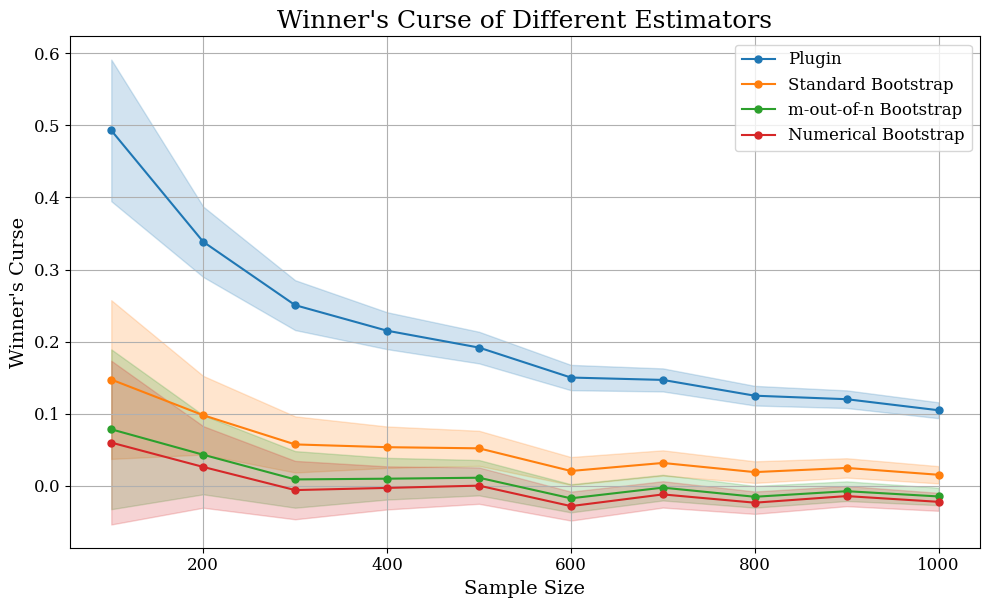

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plugin estimator
ax.plot(result_df.index, result_df['plugin_wc_mean'], 'o-', markersize=5, label='Plugin', color='C0')
ax.fill_between(
    result_df.index, 
    result_df['plugin_wc_mean'] - 1.96 * result_df['plugin_wc_se'],
    result_df['plugin_wc_mean'] + 1.96 * result_df['plugin_wc_se'],
    color='C0', alpha=0.2
)

# standard bootstrap 
ax.plot(result_df.index, result_df['standard_bootstrap_wc_mean'], 'o-', markersize=5, label='Standard Bootstrap', color='C1')
ax.fill_between(
    result_df.index,
    result_df['standard_bootstrap_wc_mean'] - 1.96 * result_df['standard_bootstrap_wc_se'],
    result_df['standard_bootstrap_wc_mean'] + 1.96 * result_df['standard_bootstrap_wc_se'],
    color='C1', alpha=0.2
)

# m out of n bootstrap
ax.plot(result_df.index, result_df['mn_bootstrap_wc_mean'], 'o-', markersize=5, label='m-out-of-n Bootstrap', color='C2')
ax.fill_between(
    result_df.index, 
    result_df['mn_bootstrap_wc_mean'] - 1.96 * result_df['mn_bootstrap_wc_se'], 
    result_df['mn_bootstrap_wc_mean'] + 1.96 * result_df['mn_bootstrap_wc_se'], 
    color='C2', alpha=0.2
)

# numerical bootstrap
ax.plot(result_df.index, result_df['num_bootstrap_wc_mean'], 'o-', markersize=5, label='Numerical Bootstrap', color='C3')
ax.fill_between(
    result_df.index, 
    result_df['num_bootstrap_wc_mean'] - 1.96 * result_df['num_bootstrap_wc_se'], 
    result_df['num_bootstrap_wc_mean'] + 1.96 * result_df['num_bootstrap_wc_se'], 
    color='C3', alpha=0.2
)


ax.set_title("Winner's Curse of Different Estimators", fontsize=title_size)
ax.set_xlabel('Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()
ax.legend(loc='best', fontsize=legend_label_size)

plt.tight_layout()
plt.savefig('figures/case1-sample-size-test.png')
plt.show()

## Large Sample Size

In [38]:
data_params = {'sample_size': 100000}

extreme_sample_size_result_records = mtss.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True, 
    save_path='results/case2_large_sample_size.pkl'
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


In [7]:
with open('results/case2_large_sample_size.pkl', 'rb') as f:
    result_records = pickle.load(f)
result_df = pd.DataFrame.from_records(result_records)

In [11]:
for estimator in ['plugin', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']:
    avg_wc = np.nanmean(result_df[f'{estimator}_wc'])
    se_wc = np.nanstd(result_df[f'{estimator}_wc']) / np.sqrt(100000)

    avg_wc_pct = np.nanmean(result_df[f'{estimator}_wc_pct'])
    se_wc_pct = np.nanstd(result_df[f'{estimator}_wc_pct']) / np.sqrt(100000)

    print(f'{estimator}: winner\'s curse: {avg_wc:.4f} ({se_wc:.4f}), winner\'s curse (%): {avg_wc_pct:.4f} ({se_wc_pct:.4f})')

plugin: winner's curse: 0.0005 (0.0001), winner's curse (%): 0.0011 (0.0002)
standard_bootstrap: winner's curse: 0.0004 (0.0001), winner's curse (%): 0.0011 (0.0002)
mn_bootstrap: winner's curse: 0.0004 (0.0001), winner's curse (%): 0.0010 (0.0002)
num_bootstrap: winner's curse: 0.0005 (0.0001), winner's curse (%): 0.0012 (0.0002)
